                        Date  Adj Close      Close       High        Low  \
0  2020-01-02 00:00:00+00:00  68.186821  68.433998  68.433998  67.324501   
1  2020-01-03 00:00:00+00:00  67.830101  68.075996  68.687500  67.365997   
2  2020-01-06 00:00:00+00:00  69.638054  69.890503  69.916000  67.550003   
3  2020-01-07 00:00:00+00:00  69.503548  69.755501  70.175003  69.578003   
4  2020-01-08 00:00:00+00:00  69.998253  70.251999  70.592499  69.631500   

        Open    Volume  
0  67.420502  27278000  
1  67.400002  23408000  
2  67.581497  46768000  
3  70.023003  34330000  
4  69.740997  35314000  
Shape of X_train: (1198, 60, 1)


C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0590
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.6477e-04
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.2196e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.7200e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.8002e-04  
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.4599e-04 
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.2268e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.5288e-04 
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.2860e-04 
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9254e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 4.9675e-04 
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.5187e-04 
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.9496e-04 
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.5188e-04
Epoch 15/20

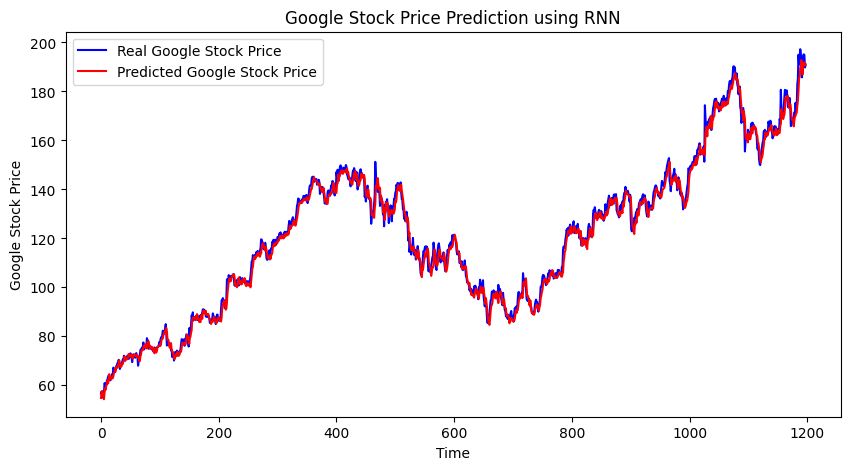

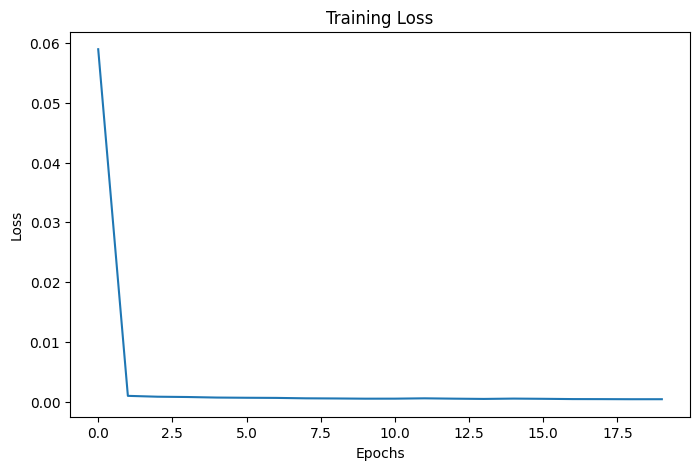


Sample Predictions:

Actual Price    : 56.63199997
Predicted Price : 54.849304
-----------------------------------
Actual Price    : 57.43650055
Predicted Price : 57.516506
-----------------------------------
Actual Price    : 56.20000076
Predicted Price : 57.678185
-----------------------------------
Actual Price    : 55.0
Predicted Price : 55.882263
-----------------------------------
Actual Price    : 55.73550034
Predicted Price : 55.233192
-----------------------------------


In [1]:
# =========================================================
# Google Stock Price Prediction using RNN
# =========================================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# =========================================================
# Load Dataset
# =========================================================

# Read CSV file
# skiprows=2 removes unwanted rows (Ticker, NaN rows)
df = pd.read_csv(r"C:\Users\ACER\Downloads\Google_Stock_Price.csv", skiprows=2)

# Rename columns properly
df.columns = [
    'Date',
    'Adj Close',
    'Close',
    'High',
    'Low',
    'Open',
    'Volume'
]

# Display first 5 rows
print(df.head())

# =========================================================
# Select Open Price Column
# =========================================================

# Use Open price for prediction
data = df['Open'].values

# Convert into 2D array
data = data.reshape(-1,1)

# =========================================================
# Feature Scaling
# =========================================================

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))

data_scaled = scaler.fit_transform(data)

# =========================================================
# Create Training Data
# =========================================================

X_train = []
y_train = []

# Use previous 60 days to predict next day
for i in range(60, len(data_scaled)):

    X_train.append(data_scaled[i-60:i, 0])

    y_train.append(data_scaled[i, 0])

# Convert lists into arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

# =========================================================
# Reshape Data for RNN
# =========================================================

# RNN requires 3D input:
# (samples, timesteps, features)

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

print("Shape of X_train:", X_train.shape)

# 

# Build RNN Model
# =========================================================

model = Sequential()

# Add RNN Layer
model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

# Add Output Layer
model.add(Dense(1))

# =========================================================
# Compile Model
# =========================================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# =========================================================
# Train Model
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

# =========================================================
# Predict Stock Prices
# =========================================================

predicted_stock_price = model.predict(X_train)

# Convert scaled values back to original prices
predicted_stock_price = scaler.inverse_transform(
    predicted_stock_price
)

real_stock_price = scaler.inverse_transform(
    y_train.reshape(-1,1)
)

# =========================================================
# Visualize Results
# =========================================================

plt.figure(figsize=(10,5))

# Real Prices
plt.plot(
    real_stock_price,
    color='blue',
    label='Real Google Stock Price'
)

# Predicted Prices
plt.plot(
    predicted_stock_price,
    color='red',
    label='Predicted Google Stock Price'
)

plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()

    ==========================================
# Print Sample Predictions
# =========================================================

print("\nSample Predictions:\n")

for i in range(5):

    print("Actual Price    :", real_stock_price[i][0])

    print("Predicted Price :", predicted_stock_price[i][0])

    print("-----------------------------------")